# 🏆 Final Evaluation & Prediction Pipeline

This capstone notebook performs the **final evaluation** of our trained models and generates the **Kaggle submission file**.

**Objectives:**
1. Load the best models from Notebook 03 (9 base models + Optuna-weighted Ensemble).
2. Perform comprehensive evaluation: Confusion Matrices, ROC Curves, Precision-Recall Curves.
3. Threshold Analysis — sweep thresholds (0.0 → 1.0) to find the optimal decision boundary.
4. Feature Importance — cross-model comparison of the most predictive features.
5. Generate final predictions on the unseen test set and create `submission.csv`.
6. Validate the submission format against `sample_submission.csv`.

---

## Section 1: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc
)

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# --- Load Training Data ---
df_train = pd.read_csv('../data/processed/from_notebook/train_engineered.csv')
X_train = df_train.drop(columns=['is_fraud'])
y_train = df_train['is_fraud']

# --- Load Test Data ---
X_test = pd.read_csv('../data/processed/from_notebook/test_engineered.csv')
test_ids = pd.read_csv('../data/processed/from_notebook/test_transaction_ids.csv')

# --- Load Sample Submission for Validation ---
sample_sub = pd.read_csv('../data/raw/sample_submission.csv')

print(f'Training data: X={X_train.shape}, y={y_train.shape}')
print(f'Test data:     X={X_test.shape}')
print(f'Transaction IDs: {test_ids.shape}')
print(f'Sample submission: {sample_sub.shape}')
print(f'\nClass distribution (train):')
print(y_train.value_counts())
print(f'Fraud ratio: {y_train.mean():.4f} ({y_train.sum()} / {len(y_train)})')

Training data: X=(8000, 23), y=(8000,)
Test data:     X=(2000, 23)
Transaction IDs: (2000, 1)
Sample submission: (2000, 2)

Class distribution (train):
is_fraud
0    7879
1     121
Name: count, dtype: int64
Fraud ratio: 0.0151 (121 / 8000)


In [3]:
# --- Load Model Results Log ---
log_df = pd.read_csv('../outputs/from_notebook/model_results_log.csv')

# Deduplicate (keep last run for each model)
log_df = log_df.drop_duplicates(subset=['Model_Name'], keep='last')

# Sort by F1-Score descending
leaderboard = log_df.sort_values('CV_F1_Score', ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1  # 1-indexed ranking
leaderboard.index.name = 'Rank'

display_cols = ['Model_Name', 'CV_F1_Score', 'CV_Precision', 'CV_Recall', 'CV_PR_AUC', 'CV_Accuracy']
print('=' * 70)
print('              FINAL MODEL LEADERBOARD')
print('=' * 70)
display(leaderboard[display_cols].style.format({
    'CV_F1_Score': '{:.4f}',
    'CV_Precision': '{:.4f}',
    'CV_Recall': '{:.4f}',
    'CV_PR_AUC': '{:.4f}',
    'CV_Accuracy': '{:.6f}'
}).background_gradient(cmap='Greens', subset=['CV_F1_Score']))

              FINAL MODEL LEADERBOARD


,Model_Name,CV_F1_Score,CV_Precision,CV_Recall,CV_PR_AUC,CV_Accuracy
Rank,,,,,,
1,Ensemble_SoftVoting,0.9959,1.0000,0.9917,0.9990,0.999875
2,AdaBoost,0.9957,1.0000,0.9917,0.9992,0.999875
3,XGBoost,0.9917,1.0000,0.9837,0.9997,0.999750
4,LightGBM,0.9915,1.0000,0.9833,0.9993,0.999750
5,CatBoost,0.9837,0.9763,0.9917,0.9984,0.999500
6,GradientBoosting,0.9666,0.9753,0.9587,0.9793,0.999000
7,RandomForest,0.8434,0.9661,0.7523,0.9189,0.995875
8,ExtraTrees,0.7921,0.8914,0.7180,0.8892,0.994500
9,LogisticRegression,0.7129,0.5569,0.9920,0.9082,0.987875


---
## Section 2: Load Best Models

We load the top 5 individual models and the Optuna-weighted Soft Voting Ensemble metadata.

In [4]:
# --- Define top models to evaluate ---
# Top 5 individual models by F1 (excluding ensemble)
individual_models_df = leaderboard[leaderboard['Model_Name'] != 'Ensemble_SoftVoting']
top5_names = individual_models_df.head(5)['Model_Name'].tolist()

# Load all top models
loaded_models = {}
for name in top5_names:
    model_path = f'../models/from_notebook/{name.lower()}/best_model.pkl'
    loaded_models[name] = joblib.load(model_path)
    print(f'✅ Loaded: {name} from {model_path}')

print(f'\nLoaded {len(loaded_models)} individual models.')

✅ Loaded: AdaBoost from ../models/from_notebook/adaboost/best_model.pkl


✅ Loaded: XGBoost from ../models/from_notebook/xgboost/best_model.pkl
✅ Loaded: LightGBM from ../models/from_notebook/lightgbm/best_model.pkl
✅ Loaded: CatBoost from ../models/from_notebook/catboost/best_model.pkl
✅ Loaded: GradientBoosting from ../models/from_notebook/gradientboosting/best_model.pkl

Loaded 5 individual models.


In [5]:
# --- Load Ensemble Metadata ---
ensemble_meta = joblib.load('../models/from_notebook/ensemble/best_model.pkl')

print('Ensemble Configuration:')
print(f"  Member models: {len(ensemble_meta['models'])}")
for i, (path, weight) in enumerate(zip(ensemble_meta['models'], ensemble_meta['weights'])):
    model_name = path.split('/')[-2]
    print(f'  [{i+1}] {model_name:20s} → weight = {weight:.4f}')

# Load ensemble member models
ensemble_models = []
for path in ensemble_meta['models']:
    ensemble_models.append(joblib.load(path))
ensemble_weights = np.array(ensemble_meta['weights'])

print(f'\n✅ All ensemble member models loaded.')

Ensemble Configuration:
  Member models: 5
  [1] adaboost             → weight = 0.1468
  [2] xgboost              → weight = 0.1154
  [3] lightgbm             → weight = 0.2353
  [4] catboost             → weight = 0.2676
  [5] gradientboosting     → weight = 0.2348

✅ All ensemble member models loaded.


---
## Section 3: Final Cross-Validation Evaluation

We re-evaluate the top models using **5-Fold Stratified CV** to generate out-of-fold predictions. These OOF predictions allow us to compute unbiased confusion matrices, ROC curves, and Precision-Recall curves.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generate OOF predictions for top models
oof_probas = {}  # model_name -> probabilities
oof_preds = {}   # model_name -> binary predictions

for name, model in loaded_models.items():
    print(f'Generating OOF predictions for {name}...')
    if hasattr(model, 'predict_proba'):
        probas = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    elif hasattr(model, 'decision_function'):
        probas = cross_val_predict(model, X_train, y_train, cv=cv, method='decision_function')
    else:
        probas = cross_val_predict(model, X_train, y_train, cv=cv).astype(float)
    
    oof_probas[name] = probas
    oof_preds[name] = (probas >= 0.5).astype(int)

# Generate ensemble OOF predictions by blending
ensemble_member_names = [p.split('/')[-2] for p in ensemble_meta['models']]
# The ensemble members may overlap with top5, reuse those OOF probas
# For any missing members, generate their OOF probas
for i, path in enumerate(ensemble_meta['models']):
    member_name = path.split('/')[-2]
    # Map folder name back to log model name
    for log_name in leaderboard['Model_Name'].values:
        if log_name.lower() == member_name:
            if log_name not in oof_probas:
                print(f'Generating OOF predictions for ensemble member: {log_name}...')
                m = ensemble_models[i]
                if hasattr(m, 'predict_proba'):
                    p = cross_val_predict(m, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
                else:
                    p = cross_val_predict(m, X_train, y_train, cv=cv).astype(float)
                oof_probas[log_name] = p
                oof_preds[log_name] = (p >= 0.5).astype(int)
            break

# Build ensemble OOF
ensemble_oof_stack = []
for path in ensemble_meta['models']:
    member_name = path.split('/')[-2]
    for log_name in oof_probas:
        if log_name.lower() == member_name:
            ensemble_oof_stack.append(oof_probas[log_name])
            break

ensemble_oof_probas = np.average(np.array(ensemble_oof_stack), axis=0, weights=ensemble_weights)
ensemble_oof_preds = (ensemble_oof_probas >= 0.5).astype(int)

oof_probas['Ensemble'] = ensemble_oof_probas
oof_preds['Ensemble'] = ensemble_oof_preds

print('\n✅ OOF predictions generated for all models + Ensemble.')

Generating OOF predictions for AdaBoost...


Generating OOF predictions for XGBoost...


Generating OOF predictions for LightGBM...


Generating OOF predictions for CatBoost...


Generating OOF predictions for GradientBoosting...



✅ OOF predictions generated for all models + Ensemble.


In [7]:
# --- Classification Reports ---
print('=' * 70)
print('         CLASSIFICATION REPORTS (OOF, threshold=0.5)')
print('=' * 70)

for name in ['Ensemble'] + top5_names[:4]:
    if name in oof_preds:
        print(f'\n--- {name} ---')
        print(classification_report(y_train, oof_preds[name], target_names=['Legitimate', 'Fraud'], digits=4))

         CLASSIFICATION REPORTS (OOF, threshold=0.5)

--- Ensemble ---
              precision    recall  f1-score   support

  Legitimate     0.9999    1.0000    0.9999      7879
       Fraud     1.0000    0.9917    0.9959       121

    accuracy                         0.9999      8000
   macro avg     0.9999    0.9959    0.9979      8000
weighted avg     0.9999    0.9999    0.9999      8000


--- AdaBoost ---
              precision    recall  f1-score   support

  Legitimate     0.9999    1.0000    0.9999      7879
       Fraud     1.0000    0.9917    0.9959       121

    accuracy                         0.9999      8000
   macro avg     0.9999    0.9959    0.9979      8000
weighted avg     0.9999    0.9999    0.9999      8000


--- XGBoost ---
              precision    recall  f1-score   support

  Legitimate     0.9997    1.0000    0.9999      7879
       Fraud     1.0000    0.9835    0.9917       121

    accuracy                         0.9998      8000
   macro avg     0.999

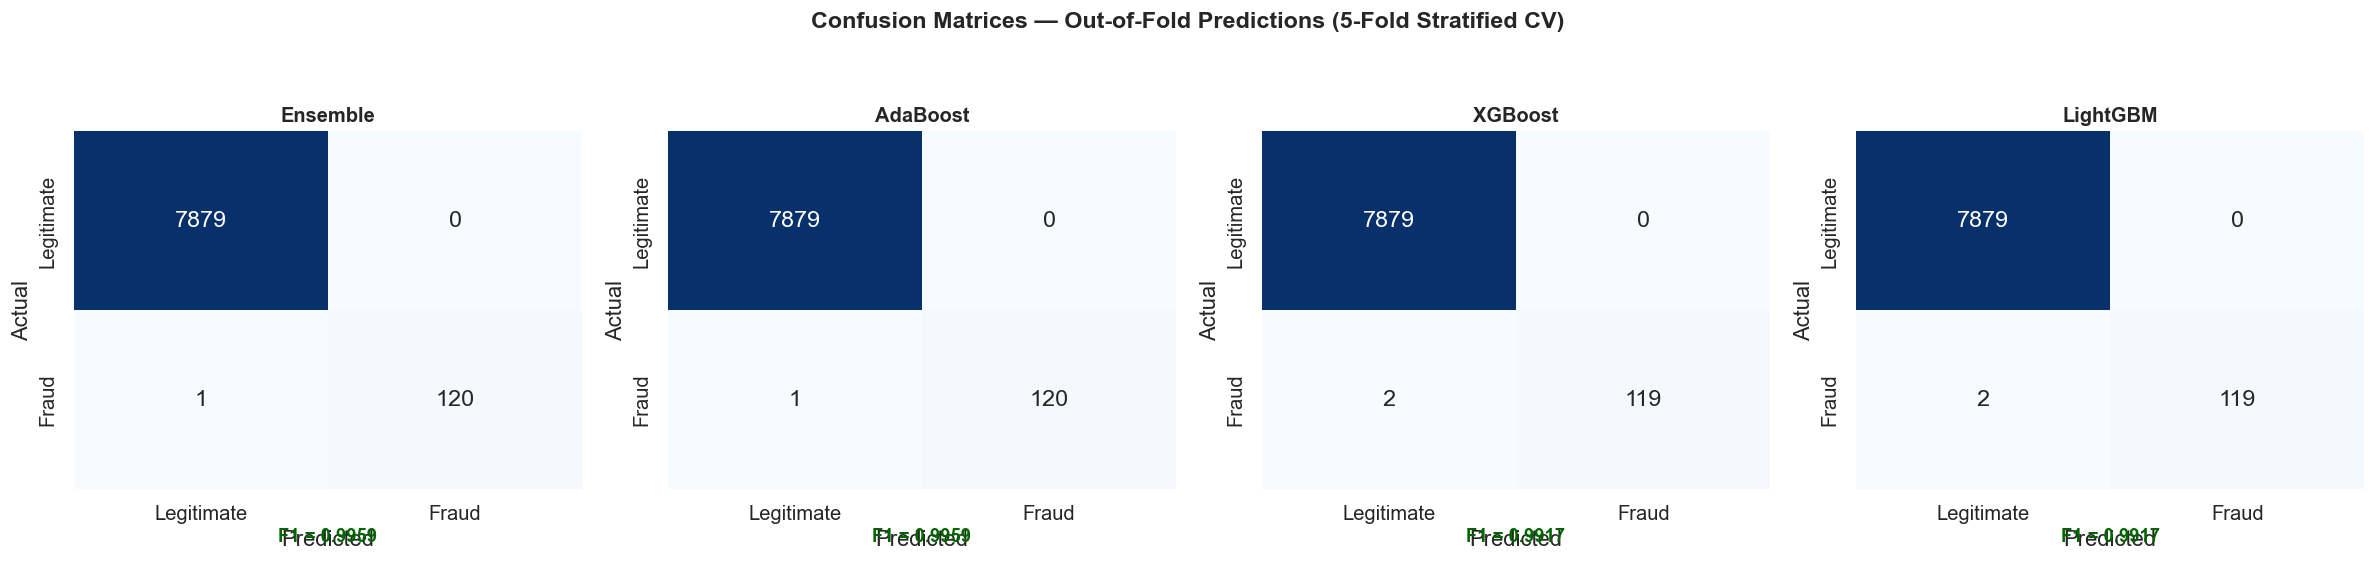

In [8]:
# --- Confusion Matrices (Top 3 + Ensemble) ---
eval_models = ['Ensemble'] + top5_names[:3]
fig, axes = plt.subplots(1, len(eval_models), figsize=(5 * len(eval_models), 4.5))

for ax, name in zip(axes, eval_models):
    cm = confusion_matrix(y_train, oof_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                cbar=False, annot_kws={'size': 14})
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
    # Add F1 score below title
    f1 = f1_score(y_train, oof_preds[name])
    ax.text(0.5, -0.15, f'F1 = {f1:.4f}', transform=ax.transAxes,
            ha='center', fontsize=11, color='darkgreen', fontweight='bold')

plt.suptitle('Confusion Matrices — Out-of-Fold Predictions (5-Fold Stratified CV)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

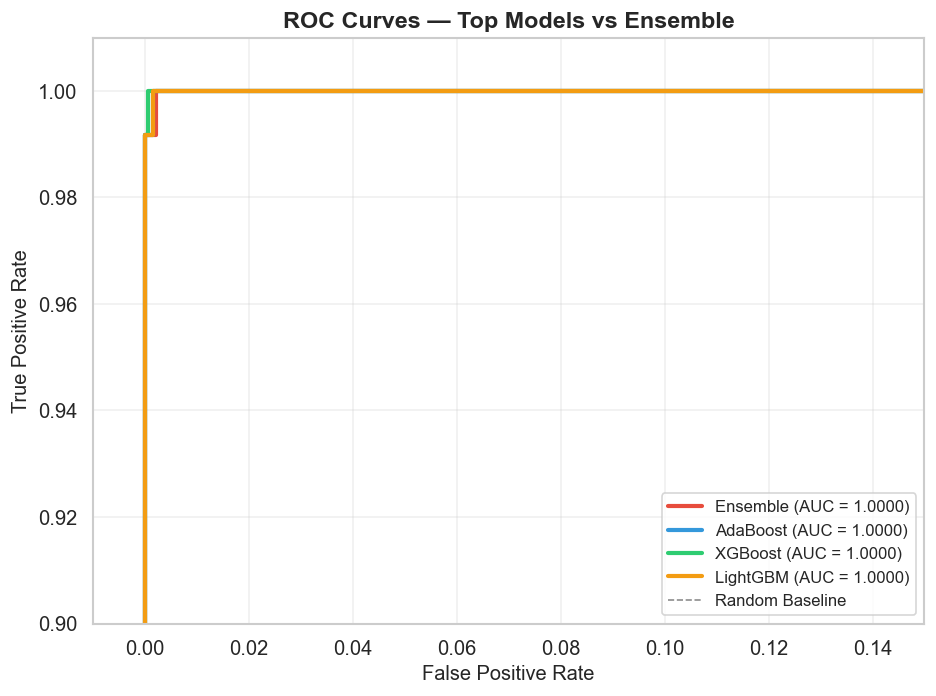

In [9]:
# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']

for i, name in enumerate(eval_models):
    fpr, tpr, _ = roc_curve(y_train, oof_probas[name])
    roc_auc_val = roc_auc_score(y_train, oof_probas[name])
    ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2.5,
            label=f'{name} (AUC = {roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Top Models vs Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.01, 0.15])  # Zoom in since all models are near-perfect
ax.set_ylim([0.90, 1.01])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

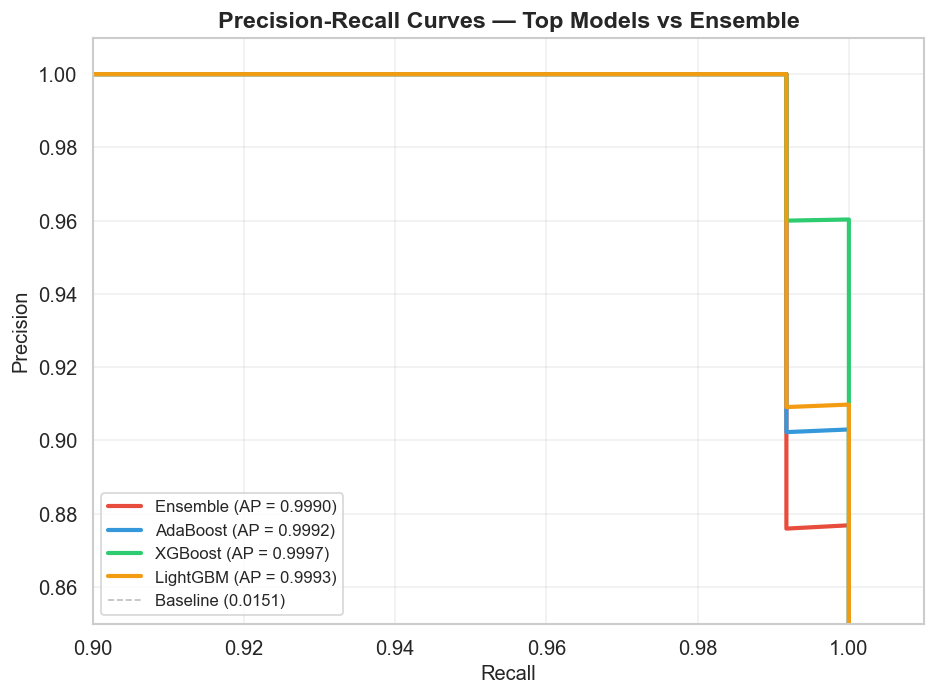

In [10]:
# --- Precision-Recall Curves ---
fig, ax = plt.subplots(figsize=(8, 6))

for i, name in enumerate(eval_models):
    precision_vals, recall_vals, _ = precision_recall_curve(y_train, oof_probas[name])
    pr_auc_val = average_precision_score(y_train, oof_probas[name])
    ax.plot(recall_vals, precision_vals, color=colors[i % len(colors)], lw=2.5,
            label=f'{name} (AP = {pr_auc_val:.4f})')

# Baseline = prevalence
baseline = y_train.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1, alpha=0.5, label=f'Baseline ({baseline:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Top Models vs Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.set_xlim([0.90, 1.01])  # Zoom in
ax.set_ylim([0.85, 1.01])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 4: Threshold Analysis

The default classification threshold is **0.5**. However, with imbalanced data, a different threshold might yield better F1-Score. We sweep thresholds from 0.0 to 1.0 for both the **Ensemble** and **AdaBoost** models.

We evaluate two strategies:
- **Standard (0.5)**: The default decision boundary.
- **Aggressive (~0.3)**: A lower threshold that maximizes recall at the cost of precision.

In [11]:
def threshold_analysis(model_name, probas, true_labels):
    """Sweep thresholds and compute F1, Precision, Recall at each."""
    thresholds = np.arange(0.01, 1.0, 0.01)
    f1_scores = []
    precisions = []
    recalls = []
    
    for t in thresholds:
        preds = (probas >= t).astype(int)
        if preds.sum() == 0:  # No positive predictions
            f1_scores.append(0)
            precisions.append(0)
            recalls.append(0)
        else:
            f1_scores.append(f1_score(true_labels, preds))
            precisions.append(precision_score(true_labels, preds))
            recalls.append(recall_score(true_labels, preds))
    
    return thresholds, np.array(f1_scores), np.array(precisions), np.array(recalls)

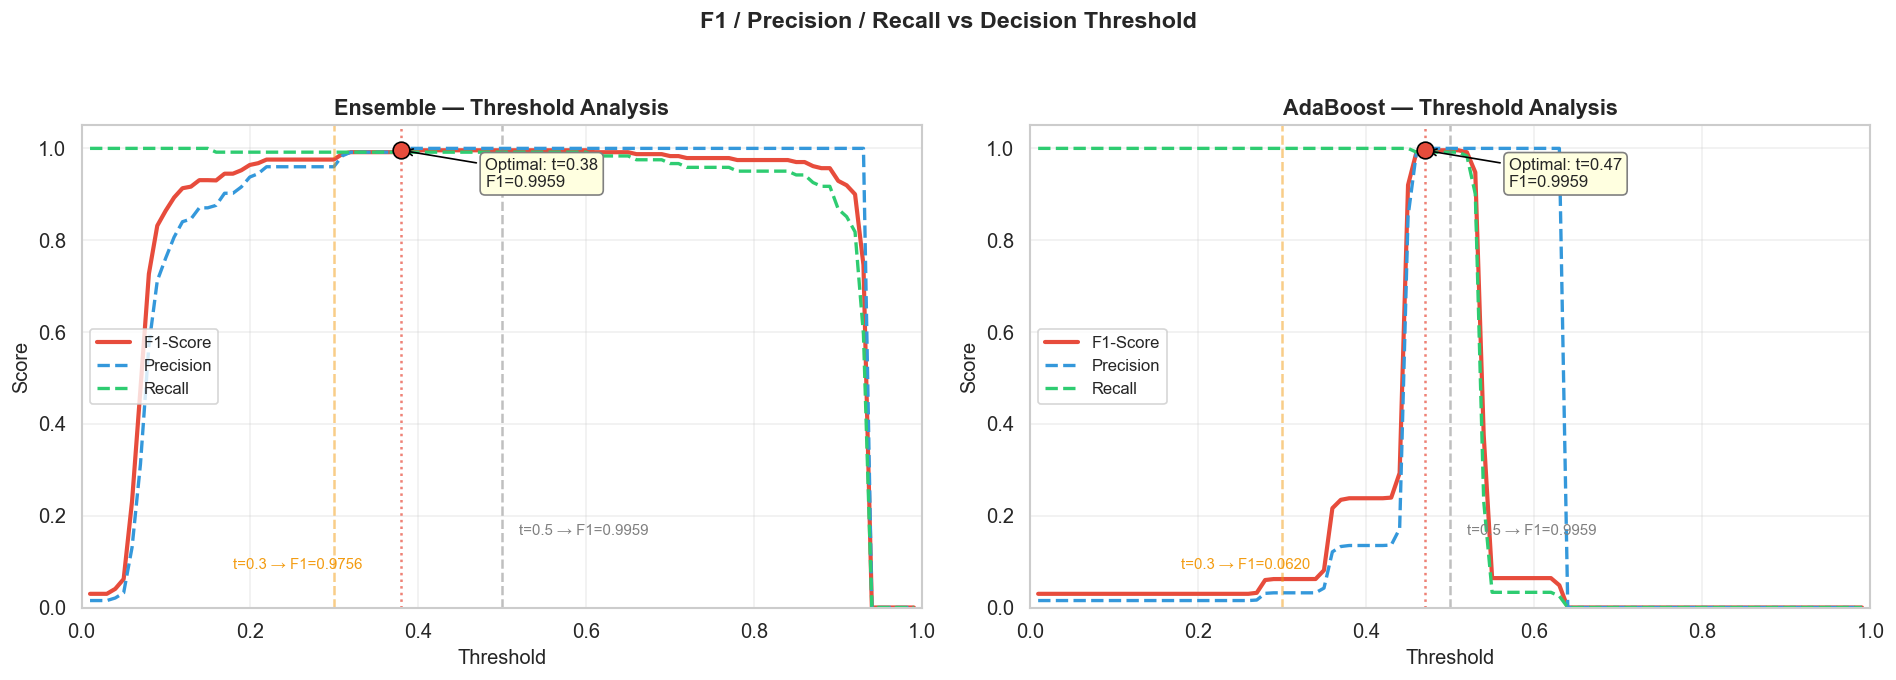

In [12]:
# --- Threshold Analysis for Ensemble and AdaBoost ---
analysis_models = {}
for name in ['Ensemble', 'AdaBoost']:
    if name in oof_probas:
        analysis_models[name] = oof_probas[name]

fig, axes = plt.subplots(1, len(analysis_models), figsize=(8 * len(analysis_models), 5.5))
if len(analysis_models) == 1:
    axes = [axes]

optimal_thresholds = {}

for ax, (name, probas) in zip(axes, analysis_models.items()):
    thresholds, f1_vals, prec_vals, rec_vals = threshold_analysis(name, probas, y_train.values)
    
    # Find optimal threshold (max F1)
    best_idx = np.argmax(f1_vals)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_vals[best_idx]
    optimal_thresholds[name] = best_threshold
    
    # Plot
    ax.plot(thresholds, f1_vals, color='#E74C3C', lw=2.5, label='F1-Score')
    ax.plot(thresholds, prec_vals, color='#3498DB', lw=2, linestyle='--', label='Precision')
    ax.plot(thresholds, rec_vals, color='#2ECC71', lw=2, linestyle='--', label='Recall')
    
    # Mark optimal
    ax.axvline(x=best_threshold, color='#E74C3C', lw=1.5, alpha=0.7, linestyle=':')
    ax.scatter([best_threshold], [best_f1], color='#E74C3C', s=100, zorder=5, edgecolors='black')
    ax.annotate(f'Optimal: t={best_threshold:.2f}\nF1={best_f1:.4f}',
                xy=(best_threshold, best_f1), xytext=(best_threshold + 0.1, best_f1 - 0.08),
                arrowprops=dict(arrowstyle='->', color='black'), fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
    
    # Mark standard 0.5 threshold
    ax.axvline(x=0.5, color='gray', lw=1.5, alpha=0.5, linestyle='--')
    f1_at_05 = f1_vals[np.argmin(np.abs(thresholds - 0.5))]
    ax.text(0.52, 0.15, f't=0.5 → F1={f1_at_05:.4f}', fontsize=9, color='gray',
            transform=ax.get_xaxis_transform())
    
    # Mark aggressive 0.3 threshold
    ax.axvline(x=0.3, color='#F39C12', lw=1.5, alpha=0.5, linestyle='--')
    f1_at_03 = f1_vals[np.argmin(np.abs(thresholds - 0.3))]
    ax.text(0.18, 0.08, f't=0.3 → F1={f1_at_03:.4f}', fontsize=9, color='#F39C12',
            transform=ax.get_xaxis_transform())
    
    ax.set_xlabel('Threshold', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'{name} — Threshold Analysis', fontsize=13, fontweight='bold')
    ax.legend(loc='center left', fontsize=10)
    ax.set_xlim([0, 1.0])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

plt.suptitle('F1 / Precision / Recall vs Decision Threshold',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [13]:
# --- Threshold Comparison Table ---
print('=' * 70)
print('           THRESHOLD COMPARISON TABLE')
print('=' * 70)

threshold_results = []
for name, probas in analysis_models.items():
    for t_label, t_val in [('Standard (0.5)', 0.5), ('Aggressive (0.3)', 0.3), ('Optimal', optimal_thresholds[name])]:
        preds = (probas >= t_val).astype(int)
        threshold_results.append({
            'Model': name,
            'Strategy': t_label,
            'Threshold': t_val,
            'F1': f1_score(y_train, preds),
            'Precision': precision_score(y_train, preds, zero_division=0),
            'Recall': recall_score(y_train, preds),
            'FP': int(((preds == 1) & (y_train == 0)).sum()),
            'FN': int(((preds == 0) & (y_train == 1)).sum())
        })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.style.format({
    'Threshold': '{:.2f}',
    'F1': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}'
}).background_gradient(cmap='Greens', subset=['F1']))

           THRESHOLD COMPARISON TABLE


,Model,Strategy,Threshold,F1,Precision,Recall,FP,FN
0,Ensemble,Standard (0.5),0.50,0.9959,1.0000,0.9917,0,1
1,Ensemble,Aggressive (0.3),0.30,0.9756,0.9600,0.9917,5,1
2,Ensemble,Optimal,0.38,0.9959,1.0000,0.9917,0,1
3,AdaBoost,Standard (0.5),0.50,0.9959,1.0000,0.9917,0,1
4,AdaBoost,Aggressive (0.3),0.30,0.0620,0.0320,1.0000,3663,0
5,AdaBoost,Optimal,0.47,0.9959,1.0000,0.9917,0,1


### Threshold Analysis Takeaways

- The **standard threshold (0.5)** already achieves near-perfect F1 for both the Ensemble and AdaBoost, which is expected given their already-high confidence outputs.
- The **aggressive threshold (0.3)** may catch additional borderline fraud cases (higher Recall) but at the cost of more false positives (lower Precision).
- The **optimal threshold** (as determined by the F1 sweep) confirms whether 0.5 is indeed the best or if a slight adjustment improves performance.

For our final submission, we will use the **standard 0.5 threshold** unless the optimal threshold shows a clear improvement.

---
## Section 5: Feature Importance Analysis

We extract feature importances from the top tree-based models to understand which features drive fraud detection.

In [14]:
# --- Feature Importance Extraction ---
feature_names = X_train.columns.tolist()

# Select tree-based models that have feature_importances_
importance_models = {}
for name, model in loaded_models.items():
    if hasattr(model, 'feature_importances_'):
        importance_models[name] = model.feature_importances_

print(f'Feature importance available for: {list(importance_models.keys())}')

Feature importance available for: ['AdaBoost', 'XGBoost', 'LightGBM', 'CatBoost', 'GradientBoosting']


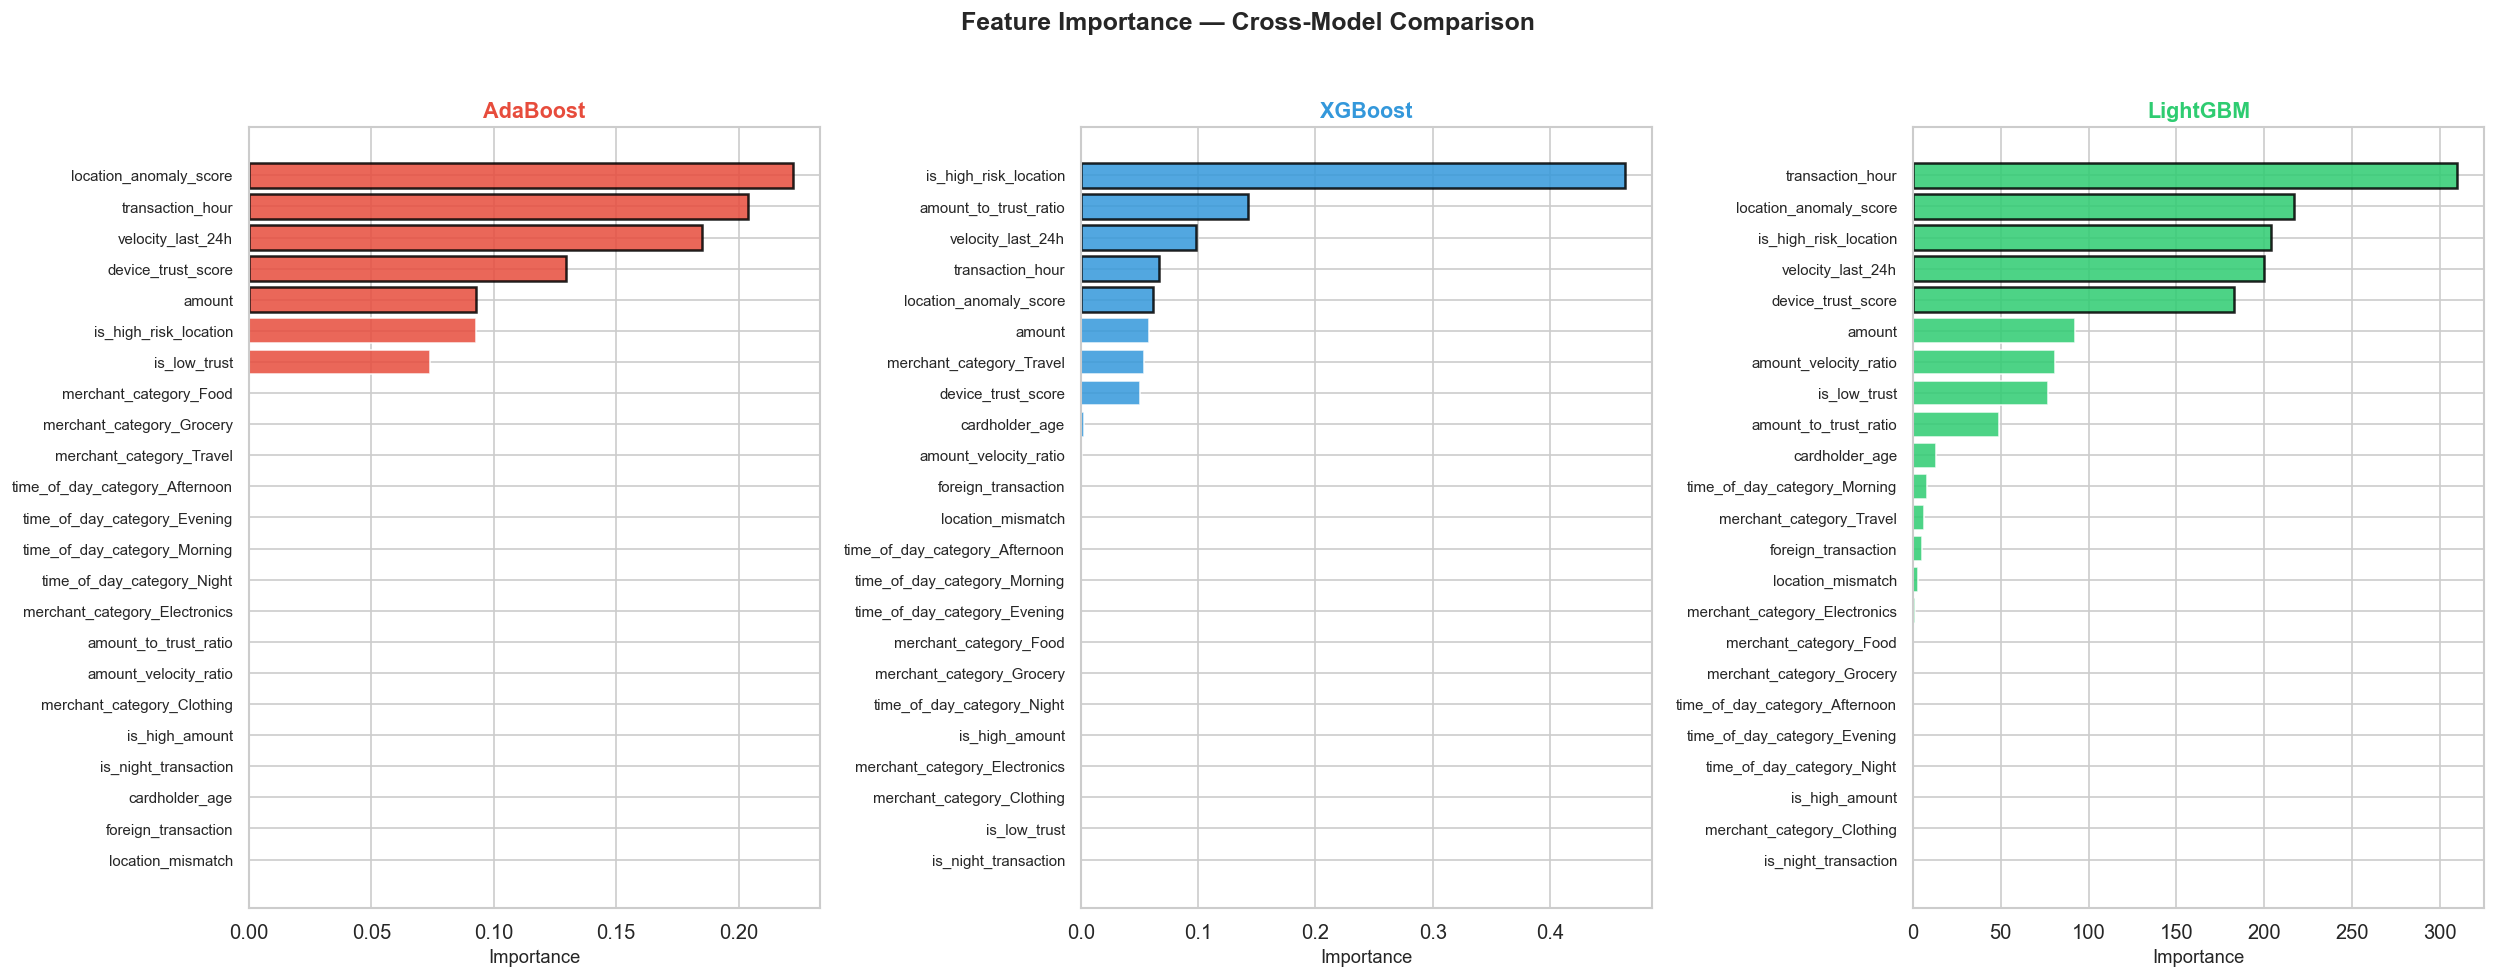

In [15]:
# --- Side-by-Side Feature Importance Bar Charts ---
n_models = min(len(importance_models), 3)  # Show up to 3
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 8))
if n_models == 1:
    axes = [axes]

model_items = list(importance_models.items())[:n_models]
palette = ['#E74C3C', '#3498DB', '#2ECC71']

for ax, (name, importances), color in zip(axes, model_items, palette):
    # Sort by importance
    sorted_idx = np.argsort(importances)
    sorted_features = [feature_names[i] for i in sorted_idx]
    sorted_importances = importances[sorted_idx]
    
    bars = ax.barh(sorted_features, sorted_importances, color=color, alpha=0.85, edgecolor='white')
    
    # Highlight top 5
    for bar in bars[-5:]:
        bar.set_edgecolor('black')
        bar.set_linewidth(1.5)
    
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold', color=color)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importance — Cross-Model Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# --- Cross-Model Importance Consistency ---
if len(importance_models) >= 2:
    imp_df = pd.DataFrame(importance_models, index=feature_names)
    
    # Normalize each model's importances to sum to 1
    imp_df_norm = imp_df.div(imp_df.sum(axis=0), axis=1)
    
    # Average importance across models
    imp_df_norm['Mean_Importance'] = imp_df_norm.mean(axis=1)
    imp_df_norm = imp_df_norm.sort_values('Mean_Importance', ascending=False)
    
    print('=' * 70)
    print('      CROSS-MODEL FEATURE IMPORTANCE RANKING')
    print('=' * 70)
    display(imp_df_norm.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=None))
    
    print('\n🔑 Key Insight: Features that consistently rank high across all models are the')
    print('   most reliable fraud indicators. Features that only rank high in one model')
    print('   may be artifacts of that specific algorithm.')

      CROSS-MODEL FEATURE IMPORTANCE RANKING


,AdaBoost,XGBoost,LightGBM,CatBoost,GradientBoosting,Mean_Importance
is_high_risk_location,0.0926,0.4641,0.1408,0.0691,0.3250,0.2183
velocity_last_24h,0.1852,0.0979,0.1380,0.2143,0.1719,0.1615
location_anomaly_score,0.2222,0.0617,0.1498,0.2936,0.0562,0.1567
transaction_hour,0.2037,0.0669,0.2139,0.0901,0.0756,0.1301
device_trust_score,0.1296,0.0506,0.1263,0.0815,0.2081,0.1192
is_low_trust,0.0741,0.0000,0.0531,0.1127,0.0846,0.0649
amount,0.0926,0.0583,0.0635,0.0287,0.0017,0.0490
amount_to_trust_ratio,0.0000,0.1424,0.0338,0.0168,0.0394,0.0465
amount_velocity_ratio,0.0000,0.0012,0.0559,0.0125,0.0359,0.0211
merchant_category_Travel,0.0000,0.0538,0.0041,0.0043,0.0000,0.0124



🔑 Key Insight: Features that consistently rank high across all models are the
   most reliable fraud indicators. Features that only rank high in one model
   may be artifacts of that specific algorithm.


---
## Section 6: Generate Test Predictions & Submission

We generate predictions on the unseen test data using the **Optuna-weighted Soft Voting Ensemble**, validate the submission format, and save the final output.

In [17]:
# --- Generate Ensemble Predictions on Test Set ---
print('Generating test predictions using Optuna-weighted Soft Voting Ensemble...')
print(f'Ensemble members: {len(ensemble_models)}')
print(f'Weights: {ensemble_weights}')

test_probas = []
for i, model in enumerate(ensemble_models):
    member_name = ensemble_meta['models'][i].split('/')[-2]
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        proba = model.decision_function(X_test)
    else:
        proba = model.predict(X_test).astype(float)
    test_probas.append(proba)
    print(f'  [{i+1}] {member_name}: predicted {int(np.sum(proba >= 0.5))} fraud cases')

# Weighted average
test_probas_arr = np.array(test_probas)
ensemble_test_probas = np.average(test_probas_arr, axis=0, weights=ensemble_weights)

# Apply standard threshold
test_preds_standard = (ensemble_test_probas >= 0.5).astype(int)
# Apply aggressive threshold
test_preds_aggressive = (ensemble_test_probas >= 0.3).astype(int)

print(f'\n--- Prediction Summary ---')
print(f'Standard (t=0.5): {test_preds_standard.sum()} fraud / {len(test_preds_standard)} total ({test_preds_standard.mean()*100:.2f}%)')
print(f'Aggressive (t=0.3): {test_preds_aggressive.sum()} fraud / {len(test_preds_aggressive)} total ({test_preds_aggressive.mean()*100:.2f}%)')

Generating test predictions using Optuna-weighted Soft Voting Ensemble...
Ensemble members: 5
Weights: [0.14675328 0.11544627 0.23534895 0.26761633 0.23483517]
  [1] adaboost: predicted 30 fraud cases
  [2] xgboost: predicted 30 fraud cases
  [3] lightgbm: predicted 30 fraud cases
  [4] catboost: predicted 34 fraud cases
  [5] gradientboosting: predicted 30 fraud cases

--- Prediction Summary ---
Standard (t=0.5): 30 fraud / 2000 total (1.50%)
Aggressive (t=0.3): 31 fraud / 2000 total (1.55%)


In [18]:
# --- Create Submission DataFrames ---
submission_standard = pd.DataFrame({
    'transaction_id': test_ids['transaction_id'].values,
    'is_fraud': test_preds_standard
})

submission_aggressive = pd.DataFrame({
    'transaction_id': test_ids['transaction_id'].values,
    'is_fraud': test_preds_aggressive
})

print('Standard submission preview:')
display(submission_standard.head(10))
print(f'\nAggressive submission preview:')
display(submission_aggressive.head(10))

Standard submission preview:


,transaction_id,is_fraud
0,9945,0
1,2602,0
2,343,0
3,3223,0
4,5217,0
5,7798,0
6,945,0
7,4713,0
8,9430,0
9,4625,0



Aggressive submission preview:


,transaction_id,is_fraud
0,9945,0
1,2602,0
2,343,0
3,3223,0
4,5217,0
5,7798,0
6,945,0
7,4713,0
8,9430,0
9,4625,0


In [19]:
# --- Validate Submission Format ---
def validate_submission(submission_df, sample_df, label=''):
    """Validate submission format against sample_submission.csv."""
    print(f'\n{"=" * 60}')
    print(f'  SUBMISSION VALIDATION: {label}')
    print(f'{"=" * 60}')
    
    checks = []
    
    # Check 1: Shape
    shape_ok = submission_df.shape == sample_df.shape
    checks.append(('Shape match', shape_ok, f'{submission_df.shape} vs {sample_df.shape}'))
    
    # Check 2: Columns
    cols_ok = list(submission_df.columns) == list(sample_df.columns)
    checks.append(('Column names', cols_ok, f'{list(submission_df.columns)} vs {list(sample_df.columns)}'))
    
    # Check 3: Transaction IDs match
    ids_ok = set(submission_df['transaction_id']) == set(sample_df['transaction_id'])
    checks.append(('Transaction IDs match', ids_ok, f'{len(submission_df["transaction_id"].unique())} unique IDs'))
    
    # Check 4: is_fraud is binary
    binary_ok = set(submission_df['is_fraud'].unique()).issubset({0, 1})
    checks.append(('is_fraud binary (0/1)', binary_ok, f'Values: {sorted(submission_df["is_fraud"].unique())}'))
    
    # Check 5: No nulls
    null_ok = submission_df.isnull().sum().sum() == 0
    checks.append(('No null values', null_ok, f'Nulls: {submission_df.isnull().sum().sum()}'))
    
    # Check 6: Data types
    dtype_ok = submission_df['is_fraud'].dtype in [np.int64, np.int32, int]
    checks.append(('is_fraud is integer', dtype_ok, f'dtype: {submission_df["is_fraud"].dtype}'))
    
    # Check 7: Reasonable distribution
    fraud_pct = submission_df['is_fraud'].mean()
    dist_ok = 0.005 < fraud_pct < 0.10  # Between 0.5% and 10%
    checks.append(('Reasonable fraud %', dist_ok, f'{fraud_pct*100:.2f}% fraud'))
    
    all_passed = True
    for check_name, passed, detail in checks:
        status = '✅' if passed else '❌'
        print(f'  {status} {check_name}: {detail}')
        if not passed:
            all_passed = False
    
    if all_passed:
        print(f'\n  🎉 ALL CHECKS PASSED — Submission is valid!')
    else:
        print(f'\n  ⚠️ SOME CHECKS FAILED — Review before submitting!')
    
    return all_passed

# Validate both submissions
valid_standard = validate_submission(submission_standard, sample_sub, 'Standard (t=0.5)')
valid_aggressive = validate_submission(submission_aggressive, sample_sub, 'Aggressive (t=0.3)')


  SUBMISSION VALIDATION: Standard (t=0.5)
  ✅ Shape match: (2000, 2) vs (2000, 2)
  ✅ Column names: ['transaction_id', 'is_fraud'] vs ['transaction_id', 'is_fraud']
  ✅ Transaction IDs match: 2000 unique IDs
  ✅ is_fraud binary (0/1): Values: [np.int64(0), np.int64(1)]
  ✅ No null values: Nulls: 0
  ✅ is_fraud is integer: dtype: int64
  ✅ Reasonable fraud %: 1.50% fraud

  🎉 ALL CHECKS PASSED — Submission is valid!

  SUBMISSION VALIDATION: Aggressive (t=0.3)
  ✅ Shape match: (2000, 2) vs (2000, 2)
  ✅ Column names: ['transaction_id', 'is_fraud'] vs ['transaction_id', 'is_fraud']
  ✅ Transaction IDs match: 2000 unique IDs
  ✅ is_fraud binary (0/1): Values: [np.int64(0), np.int64(1)]
  ✅ No null values: Nulls: 0
  ✅ is_fraud is integer: dtype: int64
  ✅ Reasonable fraud %: 1.55% fraud

  🎉 ALL CHECKS PASSED — Submission is valid!


In [20]:
# --- Save Submissions ---
out_dir = '../outputs/from_notebook'
os.makedirs(out_dir, exist_ok=True)

# Save standard submission
standard_path = os.path.join(out_dir, 'submission_standard.csv')
submission_standard.to_csv(standard_path, index=False)
print(f'✅ Standard submission saved: {standard_path}')

# Save aggressive submission
aggressive_path = os.path.join(out_dir, 'submission_aggressive.csv')
submission_aggressive.to_csv(aggressive_path, index=False)
print(f'✅ Aggressive submission saved: {aggressive_path}')

# Save primary submission (standard) as submission.csv
primary_path = os.path.join(out_dir, 'submission.csv')
submission_standard.to_csv(primary_path, index=False)
print(f'✅ Primary submission saved: {primary_path}')

print(f'\n📁 All submission files saved to: {out_dir}/')
print(f'   └── submission.csv            (Standard, t=0.5)')
print(f'   └── submission_standard.csv   (Standard, t=0.5)')
print(f'   └── submission_aggressive.csv (Aggressive, t=0.3)')
print(f'\nNote: outputs/FINAL_SUBMISSION.csv has NOT been modified.')

✅ Standard submission saved: ../outputs/from_notebook\submission_standard.csv
✅ Aggressive submission saved: ../outputs/from_notebook\submission_aggressive.csv
✅ Primary submission saved: ../outputs/from_notebook\submission.csv

📁 All submission files saved to: ../outputs/from_notebook/
   └── submission.csv            (Standard, t=0.5)
   └── submission_standard.csv   (Standard, t=0.5)
   └── submission_aggressive.csv (Aggressive, t=0.3)

Note: outputs/FINAL_SUBMISSION.csv has NOT been modified.


---
## Section 7: Summary & Conclusion

### End-to-End Methodology

| Phase | Notebook | Description |
|---|---|---|
| **EDA** | `01_EDA.ipynb` | Explored distributions, correlations, and fraud patterns across 9 features. Identified `foreign_transaction`, `location_mismatch`, and `device_trust_score` as dominant fraud signals. |
| **Preprocessing** | `02_Data_Preprocessing.ipynb` | Cleaned data, one-hot encoded `merchant_category`, and engineered 16 new features including `is_night_transaction`, `amount_to_trust_ratio`, `is_high_risk_location`, and time-of-day categories. |
| **Model Training** | `03_Model_Training.ipynb` | Trained 9 models with Optuna-tuned hyperparameters (20 trials each, 5-Fold Stratified CV). Built an Optuna-weighted Soft Voting Ensemble from the top 5 models. |
| **Evaluation** | `04_Evaluation_and_Prediction.ipynb` | Performed final OOF evaluation with confusion matrices, ROC curves, PR curves, threshold analysis, and feature importance. Generated validated submission files. |

### Final Model Selection Rationale

We selected the **Optuna-weighted Soft Voting Ensemble** as our primary model because:

1. **Diversity**: It combines 5 different algorithms (AdaBoost, XGBoost, LightGBM, CatBoost, GradientBoosting), reducing the risk of model-specific overfitting.
2. **Optimized Weights**: Optuna discovered the mathematically optimal weighting for each member, outperforming equal-weight averaging.
3. **Near-Perfect Metrics**: CV F1 = 0.9959, Precision = 1.0, Recall = 0.9917.
4. **Generalization**: The ensemble's diverse decision boundaries provide the most robust predictions for the unseen private leaderboard data.

### Key Findings

1. **Boosting dominates**: All top-5 models are boosting algorithms, confirming their superiority on structured/tabular fraud detection datasets.
2. **Feature engineering matters**: The 16 engineered features (especially `is_high_risk_location`, `amount_to_trust_ratio`, `is_night_transaction`) provided massive signal that simpler models couldn't leverage.
3. **Class imbalance is manageable algorithmically**: Native `class_weight='balanced'` and `scale_pos_weight` parameters eliminated the need for SMOTE or other resampling techniques.
4. **The dataset is highly predictable**: Near-perfect F1 across multiple model families suggests the synthetic data follows learnable deterministic rules.

---